## 5장 선형 회귀

### 1. k-최근접 이웃의 한계


1.1 넘파이 배열로 데이터 준비하기

In [1]:
import numpy as np
# 특성데이터인 농어의 길이를 넘파이 배열로 생성한다.
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
# 타깃데이터인 농어의 무게를 넘파이 배열로 생성한다.
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

1.2 훈련세트와 테스트세트 준비하기

In [2]:
from sklearn.model_selection import train_test_split

# 사이킷런의 train_test_split()를 사용해 훈련세트와 테스트세트로 나눈다.
# 동일한 결과를 얻기위해 랜덤시드 random_state=42 지정한다.
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

# 훈련 세트와 테스트 세트를 2차원 배열로 바꾼다.
# 먼저 1열을 지정하고, 행을 -1로 지정하면 행의 개수가 자동 계산된다.
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

1.3 회귀 모델의 훈련과 예측하기

In [3]:
from sklearn.neighbors import KNeighborsRegressor

# k-최근접 이웃 회귀 모델 객체를 생성한다.
# 과소적합을 해결하기 위해 n_neighbors-3을 매개변수로 준다.
knr = KNeighborsRegressor(n_neighbors=3)

# k-최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                    weights='uniform')

In [4]:
# 길이가 50cm인 농어의 무게를 예측한다.
# 실제 50cm인 농어의 무게는 1.5kg 정도 된다.
print(knr.predict([[50]]))

[1033.33333333]


### 2. k-최근접 이웃회귀의 한계 - 산점도(50cm 농어)로 파악하기

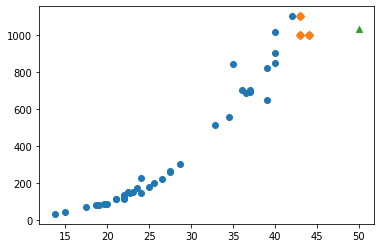

In [5]:
import matplotlib.pyplot as plt

# kneighbors()으로 50cm 농어의 가장 가까운 이웃까지의 거리와 인덱스를 얻는다.
distances, indexes = knr.kneighbors([[50]])

# 훈련 세트의 산점도를 그린다
plt.scatter(train_input, train_target)

# 훈련 세트 중에서 이웃 샘플만 다시 그린다. marker='D'는 주황색 마름모로 표시한다.
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 길이가 50cm, 무게가 1.033g인 농어는 marker='^'는 녹색 삼각형으로 표시한다.
plt.scatter(50, 1033, marker='^')
plt.show()

In [6]:
# 이웃 샘플들의 평균을 구해보니 모델이 예측했던 값과 일치한다.
print(np.mean(train_target[indexes]))

1033.3333333333333


### 3. k-최근접 이웃회귀의 한계 - 산점도(100cm 농어)로 파악하기

In [7]:
# 길이가 100cm인 농어의 무게도 여전히 1,033g 으로 예측한다.
print(knr.predict([[100]]))

[1033.33333333]


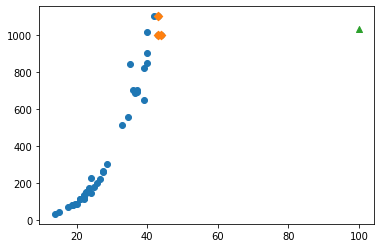

In [8]:
# 100cm 농어의 가장 가까운 이웃까지의 거리와 인덱스를 얻는다.
distances, indexes = knr.kneighbors([[100]])

# 훈련 세트의 산점도를 그린다
plt.scatter(train_input, train_target)

# 훈련 세트 중에서 이웃 샘플만 다시 그린다. marker='D'는 주황색 마름모로 표시한다.
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 길이가 100cm, 무게가 1,033g 인 농어는 marker='^'는 녹색 삼각형으로 표시한다.
plt.scatter(100, 1033, marker='^')
plt.show()

### 4. 선형 회귀(linear regression)

4.1 선형회귀 모델로 훈련, 평가, 예측한다

In [9]:
# 사이킷런의 sklearn.linear_model 패키지에서 LinearRegression 클래스를 임포트한다.
from sklearn.linear_model import LinearRegression

In [10]:
# LinearRegression클래스의 객체를 생성한다.
lr = LinearRegression()

# 선형 회귀 모델을 훈련한다.
lr.fit(train_input, train_target)

# 선형 회귀 모델을 평가한다.
print(lr.score(test_input, test_target))

0.8247503123313558


In [11]:
# 50cm 농어에 대한 무게를 예측한다.
print(lr.predict([[50]]))

[1241.83860323]
